# Recreating ALE VIM Experiments

- Example 4. Theoretical Linear Model with Correlation
- Example 5. Uniform DGP with Squared Term and Correlation on NN
- Example 6. Gaussian Copula DGP with Dummy and Correlation on NN, GBT, and RF
- Example 7. Real-world Bike Sharing Data on NN

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from tqdm.autonotebook import tqdm

from utils import bin_selection
from ale.ale import ALE

pd.options.mode.copy_on_write = True

/var/folders/z8/vqz3gnrj5xz0_b1pd775nrlm0000gn/T/ipykernel_35340/1612021041.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def replicate_ale_vim(dgp, f, n, bins=20, replications=100, categorical=None):
    """Replicate ALE variable importance."""
    nvars = dgp(1).shape[1]  # number of variables in the DGP
    vim_mains = np.zeros((replications, nvars))
    vim_connected = np.zeros((replications, nvars))
    vim_quantiles = np.zeros((replications, nvars))
    for i in tqdm(range(replications), desc="Replicating ALE VIMs"):
        X = dgp(n)
        ale = ALE(f, X, bins=bins, categorical=categorical)
        explanation = ale.explain()
        vim_mains[i, :] = explanation.loc["main"].values
        vim_connected[i, :] = explanation.loc["total_connected"].values
        vim_quantiles[i, :] = explanation.loc["total_quantile"].values

    for j in range(nvars):
        print(
            f"VIM {j + 1} Main Importance - Mean:",
            np.mean(vim_mains[:, j]),
            "CI:",
            np.percentile(vim_mains[:, j], [2.5, 97.5]),
            "SD:",
            np.std(vim_mains[:, j]),
        )
        print(
            f"VIM {j + 1} Connected Importance - Mean:",
            np.mean(vim_connected[:, j]),
            "CI:",
            np.percentile(vim_connected[:, j], [2.5, 97.5]),
            "SD:",
            np.std(vim_connected[:, j]),
        )
        print(
            f"VIM {j + 1} Quantile Importance - Mean:",
            np.mean(vim_quantiles[:, j]),
            "CI:",
            np.percentile(vim_quantiles[:, j], [2.5, 97.5]),
            "SD:",
            np.std(vim_quantiles[:, j]),
        )

    return vim_mains, vim_connected, vim_quantiles


def replicate_ale_vim_training(
    dgp, f_factory, n, bins=20, replications=100, categorical=None
):
    """Replicate ALE variable importance and train f on X."""
    nvars = dgp(1)[0].shape[1]  # number of variables in the DGP
    vim_mains = np.zeros((replications, nvars))
    vim_connected = np.zeros((replications, nvars))
    vim_quantiles = np.zeros((replications, nvars))
    for i in tqdm(range(replications), desc="Replicating ALE VIMs"):
        X, y = dgp(n)
        # maps training data to a function
        f = f_factory(X, y)
        ale = ALE(f, X, bins=bins, categorical=categorical)
        explanation = ale.explain()
        vim_mains[i, :] = explanation.loc["main"].values
        vim_connected[i, :] = explanation.loc["total_connected"].values
        vim_quantiles[i, :] = explanation.loc["total_quantile"].values

    for j in range(nvars):
        print(
            f"VIM {j + 1} Main Importance - Mean:",
            np.mean(vim_mains[:, j]),
            "CI:",
            np.percentile(vim_mains[:, j], [2.5, 97.5]),
            "SD:",
            np.std(vim_mains[:, j]),
        )
        print(
            f"VIM {j + 1} Connected Importance - Mean:",
            np.mean(vim_connected[:, j]),
            "CI:",
            np.percentile(vim_connected[:, j], [2.5, 97.5]),
            "SD:",
            np.std(vim_connected[:, j]),
        )
        print(
            f"VIM {j + 1} Quantile Importance - Mean:",
            np.mean(vim_quantiles[:, j]),
            "CI:",
            np.percentile(vim_quantiles[:, j], [2.5, 97.5]),
            "SD:",
            np.std(vim_quantiles[:, j]),
        )

    return vim_mains, vim_connected, vim_quantiles


## Example 4

In [3]:
def example_4_dgp(n, rho):
    mean = [0, 0, 0]
    # notice X3 is independent of X1 and X2
    cov = [[1, rho, 0], [rho, 1, 0], [0, 0, 1]]
    X = np.random.multivariate_normal(mean, cov, n)
    return X

def example_4_f(X, betas):
    return betas[0] * X[:, 0] + betas[1] * X[:, 1] + betas[2] * X[:, 2]

n = 1000
dgp = lambda n: example_4_dgp(n, rho=0.5)
f = lambda X: example_4_f(X, betas=[3, 2, 1])
bins = bin_selection(n)

vim_mains, vim_connected, vim_quantile = replicate_ale_vim(dgp, f, n=n, bins=bins, replications=5)


Replicating ALE VIMs:   0%|          | 0/5 [00:00<?, ?it/s]

Calculating explanations for feature 1 (X1)
Calculating explanations for feature 2 (X2)
Calculating explanations for feature 3 (X3)
Calculating explanations for feature 1 (X1)
Calculating explanations for feature 2 (X2)
Calculating explanations for feature 3 (X3)
Calculating explanations for feature 1 (X1)
Calculating explanations for feature 2 (X2)
Calculating explanations for feature 3 (X3)
Calculating explanations for feature 1 (X1)
Calculating explanations for feature 2 (X2)
Calculating explanations for feature 3 (X3)
Calculating explanations for feature 1 (X1)
Calculating explanations for feature 2 (X2)
Calculating explanations for feature 3 (X3)
VIM 1 Main Importance - Mean: 3.2603125023219226 CI: [3.13016489 3.32043041] SD: 0.07498998924233521
VIM 1 Connected Importance - Mean: 3.236946416333282 CI: [3.10707331 3.29206371] SD: 0.07441700229689338
VIM 1 Quantile Importance - Mean: 3.236946416333282 CI: [3.10707331 3.29206371] SD: 0.07441700229689338
VIM 2 Main Importance - Mean: 

## Example 5

In [4]:
def example_5_dgp(n):
    u = np.random.uniform(0, 1, n)
    x1 = u + np.random.normal(0, 0.05, n)
    x2 = u + np.random.normal(0, 0.05, n)
    X = np.column_stack((x1, x2))
    y = x1 + x2 ** 2 + np.random.normal(0, 0.1, n)
    return X, y

In [5]:
# # determine optimal hyperparameters for MLPRegressor
# def get_mlp_hyperparams(X, y):
#     # use GridSearchCV to find the best hyperparameters
#     param_grid = {
#         'hidden_layer_sizes': [(x, ) for x in np.arange(50, 101, 5)],
#         'activation': ['relu'],
#         'solver': ['adam'],
#         'alpha': 0.00001 * np.arange(1, 11),
#         'learning_rate': ['constant']
#     }
#     mlp = MLPRegressor(max_iter=1000, random_state=42)
#     grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
#     grid_search.fit(X, y)
#     return grid_search.best_params_

# X, y = example_5_dgp(200)
# best_params = get_mlp_hyperparams(X, y)
# print("Best hyperparameters:", best_params)

In [6]:
# def example_5_f_factory(X, y):
#     # train a neural network regressor
#     mlp = MLPRegressor(
#         hidden_layer_sizes=(80,),
#         activation='relu',
#         solver='adam',
#         alpha=0.00001,
#         learning_rate='constant',
#         max_iter=1000,
#         random_state=42
#     )
#     mlp.fit(X, y)
#     return lambda X: mlp.predict(X)

# n = 200
# bins = bin_selection(n)

# vim_mains, vim_connected, vim_quantile = replicate_ale_vim_training(example_5_dgp, example_5_f_factory, n=n, bins=bins, replications=100)

## Example 6

In [7]:
def example_6_dgp(n):
    # generate copula of uniform random variables
    # with specific correlation structure
    R = np.array([
        [1.0, 0.0, 0.2, 0.0],
        [0.0, 1.0, 0.9, 0.0],
        [0.2, 0.9, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])

    L = np.linalg.cholesky(R)
    Z = np.random.normal(size=(n, 4)) @ L.T
    X = stats.norm.cdf(Z)
    y = 4 * X[:, 0] + 3.87 * X[:, 1] ** 2 + 2.97 * np.exp(-5 + 10 * X[:, 2]) / (1 + np.exp(-5 + 10 * X[:, 2])) + 13.86 * (X[:, 0] - 0.5) * (X[:, 1] - 0.5) + np.random.normal(0, 0.5, X.shape[0])
    return X, y

def example_6_f_factory_mlp(X, y):
    mlp = MLPRegressor(
        hidden_layer_sizes=(80,),
        activation='relu',
        solver='adam',
        alpha=0.00001,
        learning_rate='constant',
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X, y)
    print(mlp.score(X, y))
    return lambda X: mlp.predict(X)

def example_6_f_factory_gradient_boosted_tree(X, y):
    hgbr = HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    hgbr.fit(X, y)
    print(hgbr.score(X, y))
    return lambda X: hgbr.predict(X)

def example_6_f_factory_random_forest(X, y):
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        random_state=42
    )
    rf.fit(X, y)
    print(rf.score(X, y))
    return lambda X: rf.predict(X)

n = 10000
dgp = lambda n: example_6_dgp(n)
bins = bin_selection(n)

In [8]:
# vim_mains, vim_connected, vim_quantile = replicate_ale_vim_training(dgp, example_6_f_factory_mlp, n=n, bins=bins, replications=1)

In [9]:
# vim_mains, vim_connected, vim_quantile = replicate_ale_vim_training(dgp, example_6_f_factory_gradient_boosted_tree, n=n, bins=bins, replications=1)

In [10]:
# vim_mains, vim_connected, vim_quantile = replicate_ale_vim_training(dgp, example_6_f_factory_random_forest, n=n, bins=bins, replications=1)

## Example 7

In [11]:
# clean data
df = pd.read_csv("data/uci_bikesharing.csv")
df = df.dropna()
# remove observations with missing feeling temperature or humidity values
# these observations are recorded as 0 humidity and 0.2424 feeling temperature
df = df[df["hum"] != 0]
df = df[(df["atemp"] != 0.2424) | (df["temp"] <= 0.5)]
# create quarter column
df["quarter"] = 1 + 4 * df["yr"] + df["mnth"] // 4
# rename mnth to month, hr to hour
df = df.rename(columns={"mnth": "month", "hr": "hour", "weathersit": "weather_situation"})
# keep only relevant columns
X = df[["quarter", "month", "hour", "holiday", "weekday", "workingday", "weather_situation", "atemp", "hum", "windspeed"]]
X["holiday"] = X["holiday"].astype("category")
X["workingday"] = X["workingday"].astype("category")
y = df["cnt"]

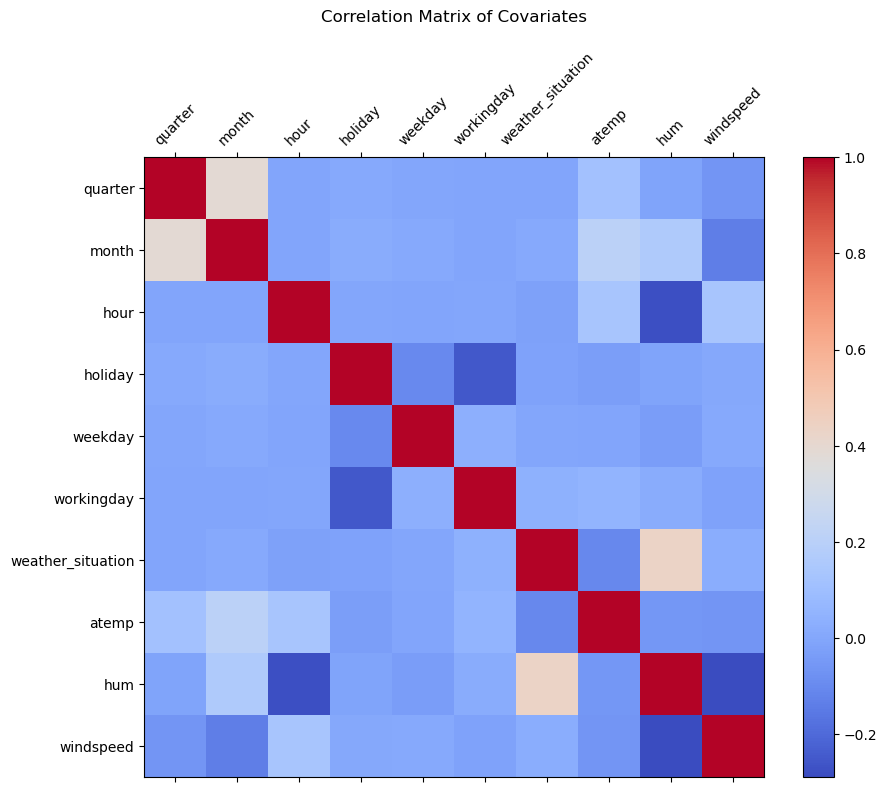

In [12]:
# correlation matrix of covariates
corr = X.corr()
plt.figure(figsize=(10, 8))
plt.matshow(corr, cmap='coolwarm', fignum=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation Matrix of Covariates', pad=20)
plt.show()

In [13]:
# # determine optimal hyperparameters for MLPRegressor
# def get_mlp_hyperparams(X, y):
#     # use GridSearchCV to find the best hyperparameters
#     param_grid = {
#         'hidden_layer_sizes': [(x, ) for x in np.arange(25, 81, 5)],
#         'activation': ['logistic'],
#         'solver': ['adam'],
#         'alpha': [0.5, 0.2, 0.1, 0.05, 0.01, 0.005],
#         'learning_rate': ['constant'],
#     }
#     mlp = MLPRegressor(max_iter=1000, random_state=42)
#     grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
#     grid_search.fit(X, y)
#     return grid_search.best_params_

# get_mlp_hyperparams(X, np.log(y))

In [14]:
def summarize_model_performance(model, X_test, y_test):
    # evaluate model performance
    y_pred = model.predict(X_test)
    y_pred = np.exp(y_pred)  # convert back to original scale
    y_true = np.exp(y_test)  # convert back to original scale
    mse = mean_squared_error(y_true, y_pred)
    print("Mean Squared Error:", mse)
    print("R^2:", model.score(X_test, y_test))

In [15]:
est = MLPRegressor(hidden_layer_sizes=(25,), activation='logistic', alpha=0.05, max_iter=1000, random_state=42)
# cv = KFold(n_splits=5, shuffle=True, random_state=42)
# for train_index, test_index in cv.split(X):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = np.log(y.iloc[train_index]), np.log(y.iloc[test_index])
    
#     # train the model
#     est.fit(X_train, y_train)
    
#     # summarize model performance
#     print("Training set performance:")
#     summarize_model_performance(est, X_train, y_train)

In [16]:
n = X.shape[0]
K = bin_selection(n)
est.fit(X, np.log(y))
# function to plug-in representing model
f = lambda x: est.predict(x)

In [17]:
ale = ALE(f, X, bins=340)
ale.explain()

Calculating explanations for feature 1 (quarter)


/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:123: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


Calculating explanations for feature 2 (month)


/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:123: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


Calculating explanations for feature 3 (hour)


...

Calculating explanations for feature 8 (atemp)


/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:123: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


Calculating explanations for feature 9 (hum)
Calculating explanations for feature 10 (windspeed)


/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:123: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


,quarter,month,hour,holiday,weekday,workingday,weather_situation,atemp,hum,windspeed
main,0.243000,0.086539,1.237151,0.020697,0.061744,0.019564,0.155507,0.290632,0.047345,0.026837
total_quantile,0.243150,0.135552,1.914681,0.044553,0.146222,0.773722,0.065125,0.309264,0.070152,0.030571
total_connected,0.245135,0.085100,1.861785,0.048429,0.119469,0.788940,0.065414,0.322674,0.059329,0.031281
